# Бенчмарки cache policies и анализ hit-rate

Этот notebook запускает проектный benchmark, сравнивает online-стратегии с offline-оптимумом Belady и строит графики для практического выбора кэша.

Главная метрика — **hit-rate, % от Belady**: `100 × hits(strategy) / hits(Belady)` на том же trace и с тем же суммарным логическим byte-бюджетом. Для 2Q/ARC/LIRS в рейтинг обязательно попадает режим `resident_and_shadow`: resident entries и shadow keys делят общий бюджет. Их legacy-прогоны `resident_only` сохраняются в исходном CSV только для диагностики и исключаются из всех рейтингов и графиков. LRU/LFU не имеют shadow items и запускаются в обычном `resident_only`. Значение 100% означает совпадение с offline-оптимумом по числу hits. Для trace без единого возможного hit метрика по принятому в benchmark соглашению равна 100%.

> Рейтинг ниже использует макро-среднее: каждый trace имеет одинаковый вес. Синтетические workloads полезны для сравнения алгоритмов, но окончательный выбор лучше подтвердить репрезентативными production traces.

In [1]:
from __future__ import annotations

import csv
import os
import re
import statistics
import subprocess
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'scripts' / 'benchmark.py').is_file():
    raise RuntimeError('Запустите notebook из корня проекта CacheResearch')

RESULTS_CSV = PROJECT_ROOT / 'results' / 'benchmark.csv'
VALUE_SIZE_RESULTS_CSV = PROJECT_ROOT / 'results' / 'value_size_benchmark.csv'
PATTERN_ORDER = ['loop', 'scan', 'uniform', 'normal', 'hotset', 'hot_scan', 'phase_change', 'zipf']
COLORS = list(plt.get_cmap('tab10').colors)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print(f'Project root: {PROJECT_ROOT}')

Project root: /home/lenoz/CLionProjects/CacheResearch


## 1. Запуск benchmark

При `RUN_BENCHMARK = True` ячейка запускает все пары generated config × workload и Belady baseline. Release-бинарник собирается автоматически, если отсутствует. Входные данные генерируются автоматически, если отсутствуют; принудительную регенерацию можно включить отдельно.

Полный штатный набор сейчас содержит 125 трёхуровневых конфигураций и 48 traces. Результат сохраняется в `results/benchmark.csv`.

In [2]:
RUN_BENCHMARK = True
RUN_VALUE_SIZE_BENCHMARK = True
REBUILD_RELEASE = False
REGENERATE_INPUTS = False
JOBS = min(8, os.cpu_count() or 1)
TIMEOUT_SECONDS = 30

executable = PROJECT_ROOT / 'build' / 'release' / 'cache_sim'
configs_dir = PROJECT_ROOT / 'configs' / 'generated' / '3-level'
workloads_dir = PROJECT_ROOT / 'workloads' / 'generated'

def run(command: list[str]) -> None:
    print('$', ' '.join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

if REBUILD_RELEASE or not executable.is_file():
    run(['cmake', '--preset', 'release'])
    run(['cmake', '--build', '--preset', 'release', '--parallel'])

inputs_missing = (
    not any(configs_dir.glob('*.conf'))
    or not any(workloads_dir.rglob('*.trace'))
)
if REGENERATE_INPUTS or inputs_missing:
    run(['python3', 'scripts/generate_configs.py', '--levels', '3', '--clean'])
    run(['python3', 'scripts/generate_workloads.py', '--levels', '3', '--clean'])

if RUN_BENCHMARK or not RESULTS_CSV.is_file():
    run([
        'python3', 'scripts/benchmark.py',
        '--executable', str(executable),
        '--configs', str(configs_dir),
        '--workloads', str(workloads_dir),
        '--output', str(RESULTS_CSV),
        '--jobs', str(JOBS),
        '--timeout', str(TIMEOUT_SECONDS),
    ])
else:
    print(f'Используется существующий файл: {RESULTS_CSV}')

value_size_configs = ['2q_2q_2q.conf', 'arc_arc_arc.conf', 'lirs_lirs_lirs.conf']
value_sizes = ['current', '64', '256', '1024']
if RUN_VALUE_SIZE_BENCHMARK or not VALUE_SIZE_RESULTS_CSV.is_file():
    run([
        'python3', 'scripts/benchmark.py',
        '--executable', str(executable),
        '--configs', str(configs_dir),
        '--workloads', str(workloads_dir),
        '--output', str(VALUE_SIZE_RESULTS_CSV),
        '--summary', str(PROJECT_ROOT / 'results' / 'value_size_best_by_workload.csv'),
        '--pattern-summary', str(PROJECT_ROOT / 'results' / 'value_size_best_by_pattern.csv'),
        '--jobs', str(JOBS),
        '--timeout', str(TIMEOUT_SECONDS),
        '--config-names', *value_size_configs,
        '--value-bytes', *value_sizes,
    ])
else:
    print(f'Используется существующий файл: {VALUE_SIZE_RESULTS_CSV}')

$ python3 scripts/benchmark.py --executable /home/lenoz/CLionProjects/CacheResearch/build/release/cache_sim --configs /home/lenoz/CLionProjects/CacheResearch/configs/generated/3-level --workloads /home/lenoz/CLionProjects/CacheResearch/workloads/generated --output /home/lenoz/CLionProjects/CacheResearch/results/benchmark.csv --jobs 8 --timeout 30


completed 580/11616 runs
completed 1160/11616 runs
completed 1740/11616 runs
completed 2320/11616 runs
completed 2900/11616 runs
completed 3480/11616 runs
completed 4060/11616 runs
completed 4640/11616 runs
completed 5220/11616 runs
completed 5800/11616 runs
completed 6380/11616 runs
completed 6960/11616 runs
completed 7540/11616 runs
completed 8120/11616 runs
completed 8700/11616 runs
completed 9280/11616 runs
completed 9860/11616 runs
completed 10440/11616 runs
completed 11020/11616 runs
completed 11600/11616 runs
completed 11616/11616 runs
wrote 11616 rows to /home/lenoz/CLionProjects/CacheResearch/results/benchmark.csv
wrote 48 best configurations to /home/lenoz/CLionProjects/CacheResearch/results/best_by_workload.csv
wrote 8 pattern winners to /home/lenoz/CLionProjects/CacheResearch/results/best_by_pattern.csv
$ python3 scripts/benchmark.py --executable /home/lenoz/CLionProjects/CacheResearch/build/release/cache_sim --configs /home/lenoz/CLionProjects/CacheResearch/configs/generat

completed 57/1152 runs
completed 114/1152 runs
completed 171/1152 runs
completed 228/1152 runs
completed 285/1152 runs
completed 342/1152 runs
completed 399/1152 runs
completed 456/1152 runs
completed 513/1152 runs
completed 570/1152 runs
completed 627/1152 runs
completed 684/1152 runs
completed 741/1152 runs
completed 798/1152 runs
completed 855/1152 runs
completed 912/1152 runs
completed 969/1152 runs
completed 1026/1152 runs
completed 1083/1152 runs
completed 1140/1152 runs
completed 1152/1152 runs
wrote 1152 rows to /home/lenoz/CLionProjects/CacheResearch/results/value_size_benchmark.csv
wrote 192 best configurations to /home/lenoz/CLionProjects/CacheResearch/results/value_size_best_by_workload.csv
wrote 32 pattern winners to /home/lenoz/CLionProjects/CacheResearch/results/value_size_best_by_pattern.csv


## 2. Загрузка и проверка данных

In [3]:
INTEGER_FIELDS = {
    'cache_size_per_level', 'total_capacity', 'requests', 'levels',
    'hits', 'misses', 'ideal_hits',
}
FLOAT_FIELDS = {'hit_rate', 'ideal_hit_rate', 'percent_of_ideal', 'seconds'}

def load_results(path: Path) -> list[dict[str, object]]:
    with path.open(encoding='utf-8', newline='') as source:
        raw_rows = list(csv.DictReader(source))

    rows: list[dict[str, object]] = []
    for raw in raw_rows:
        row: dict[str, object] = dict(raw)
        for field in INTEGER_FIELDS:
            row[field] = int(raw[field]) if raw.get(field) else None
        for field in FLOAT_FIELDS:
            row[field] = float(raw[field]) if raw.get(field) else None
        rows.append(row)
    return rows

all_rows = load_results(RESULTS_CSV)
failed_rows = [row for row in all_rows if row['status'] != 'ok']
if failed_rows:
    examples = '; '.join(f"{r['workload']}: {r['error']}" for r in failed_rows[:3])
    raise RuntimeError(f'{len(failed_rows)} benchmark runs failed. Examples: {examples}')

successful_rows = [row for row in all_rows if row['status'] == 'ok']
assert successful_rows and all(row['percent_of_ideal'] is not None for row in successful_rows), 'Нужен benchmark с Belady baseline'

SHADOW_POLICIES = {'2Q', 'ARC', 'LIRS'}

def uses_shadow_policy(row: dict[str, object]) -> bool:
    return any(policy in SHADOW_POLICIES for policy in str(row['policies']).split('>'))

def is_fair_variant(row: dict[str, object]) -> bool:
    expected_mode = 'resident_and_shadow' if uses_shadow_policy(row) else 'resident_only'
    return row.get('capacity_mode') == expected_mode

shadow_runs = [
    row for row in successful_rows
    if uses_shadow_policy(row) and row.get('capacity_mode') == 'resident_and_shadow'
]
shadow_work = {
    (str(row['config']), str(row['workload']))
    for row in successful_rows if uses_shadow_policy(row)
}
assert shadow_runs, 'В benchmark нет обязательных resident_and_shadow прогонов'
assert len(shadow_runs) == len(shadow_work), 'Не для каждого сложного cache/workload есть shadow-прогон'

excluded_unfair_rows = [
    row for row in successful_rows
    if uses_shadow_policy(row) and row.get('capacity_mode') == 'resident_only'
]
rows = [row for row in successful_rows if is_fair_variant(row)]
assert not any(uses_shadow_policy(row) and row['capacity_mode'] != 'resident_and_shadow' for row in rows)
workloads = sorted({str(row['workload']) for row in rows})
def variant_label(row: dict[str, object]) -> str:
    budget = 'shadow included' if uses_shadow_policy(row) else 'no shadow items'
    return f"{row['policies']} [{budget}]"

configs = sorted({variant_label(row) for row in rows})
patterns = [name for name in PATTERN_ORDER if any(row['pattern'] == name for row in rows)]
patterns += sorted({str(row['pattern']) for row in rows} - set(patterns))

print(f'Всего успешных benchmark-строк: {len(successful_rows):,}')
print(f'Строк в честном сравнении: {len(rows):,}')
print(f'Обязательных shadow-прогонов: {len(shadow_runs):,}')
print(f'Исключено читерских resident_only-прогонов сложных кэшей: {len(excluded_unfair_rows):,}')
print(f'Конфигураций в рейтинге: {len(configs)}')
print(f'Trace-тестов: {len(workloads)}')
print(f'Паттернов: {len(patterns)} — {", ".join(patterns)}')

Всего успешных benchmark-строк: 11,616
Строк в честном сравнении: 6,000
Обязательных shadow-прогонов: 5,616
Исключено читерских resident_only-прогонов сложных кэшей: 5,616
Конфигураций в рейтинге: 125
Trace-тестов: 48
Паттернов: 8 — loop, scan, uniform, normal, hotset, hot_scan, phase_change, zipf


In [4]:
by_config: dict[str, list[dict[str, object]]] = defaultdict(list)
for row in rows:
    by_config[variant_label(row)].append(row)

config_summary = []
for policies, group in by_config.items():
    ideal_percent = [float(row['percent_of_ideal']) for row in group]
    config_summary.append({
        'policies': policies,
        'mean_percent_of_ideal': statistics.fmean(ideal_percent),
        'median_percent_of_ideal': statistics.median(ideal_percent),
        'min_percent_of_ideal': min(ideal_percent),
        'mean_hit_rate_percent': statistics.fmean(float(row['hit_rate']) for row in group) * 100,
        'throughput_req_s': sum(int(row['requests']) for row in group) / sum(float(row['seconds']) for row in group),
        'runs': len(group),
    })

config_summary.sort(key=lambda item: (-item['mean_percent_of_ideal'], item['policies']))
top5 = [str(item['policies']) for item in config_summary[:5]]

print('Топ-5 по среднему hit-rate, % от Belady')
print(f"{'#':>2}  {'политики и режим':<45} {'mean':>8} {'median':>8} {'min':>8}")
for rank, item in enumerate(config_summary[:5], 1):
    print(
        f"{rank:>2}  {item['policies']:<45} "
        f"{item['mean_percent_of_ideal']:>7.2f}% "
        f"{item['median_percent_of_ideal']:>7.2f}% "
        f"{item['min_percent_of_ideal']:>7.2f}%"
    )

Топ-5 по среднему hit-rate, % от Belady
 #  политики и режим                                  mean   median      min
 1  LFU>LIRS>LIRS [shadow included]                 51.44%   40.61%   11.45%
 2  LFU>LFU>LIRS [shadow included]                  50.68%   39.11%   11.19%
 3  LFU>LRU>LIRS [shadow included]                  50.68%   39.11%   11.19%
 4  LIRS>LFU>LIRS [shadow included]                 48.99%   37.90%   10.07%
 5  LIRS>LRU>LIRS [shadow included]                 48.99%   37.90%   10.07%


## 3. Топ-5 стратегий на каждом trace

Стратегии отбираются по среднему проценту от Belady на всех тестах. У любой конфигурации с 2Q/ARC/LIRS в подписи должно быть `[shadow included]`; её `resident_only`-двойник сюда не допускается. По горизонтали — отдельные traces, сгруппированные по паттерну; цвет закреплён за конфигурацией. Пунктир 100% — offline optimum.

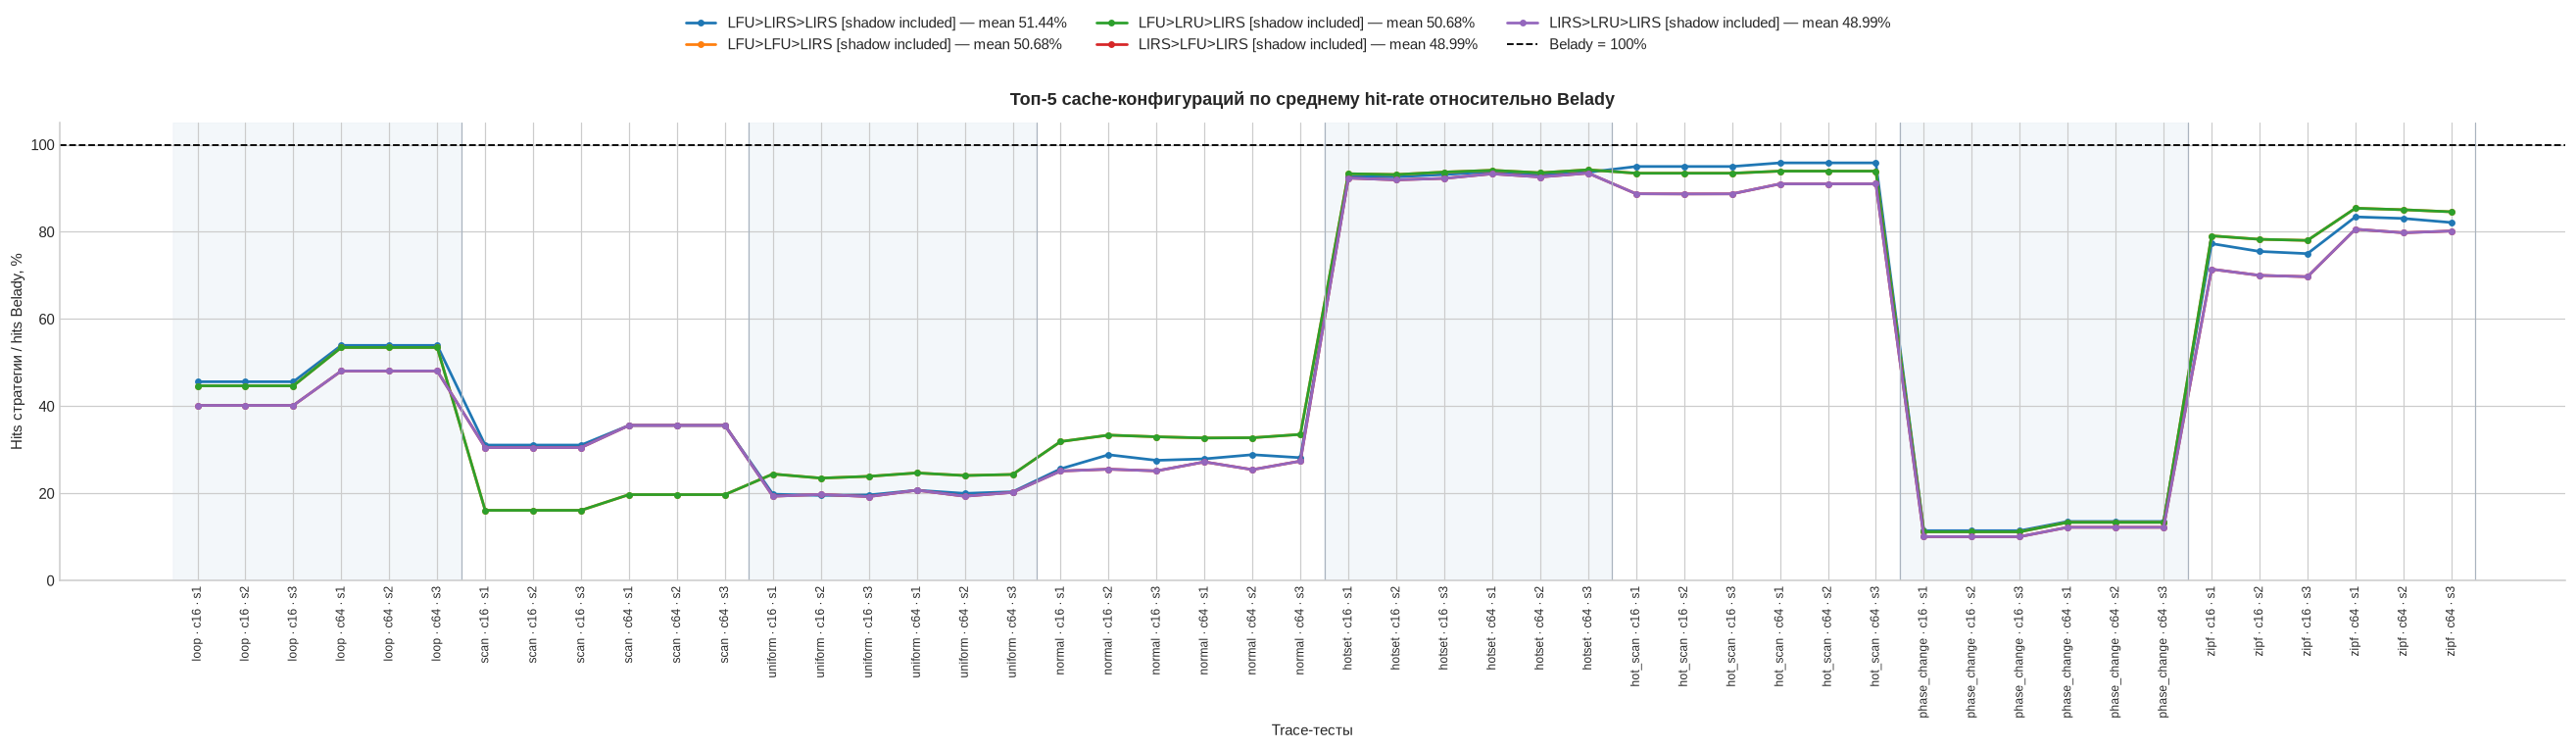

In [5]:
pattern_rank = {pattern: index for index, pattern in enumerate(patterns)}

def workload_parts(row: dict[str, object]) -> tuple[int, int]:
    match = re.search(r'_c(\d+)_n\d+_s(-?\d+)\.trace$', str(row['workload']))
    return (int(match.group(1)), int(match.group(2))) if match else (int(row['cache_size_per_level']), 0)

representative_rows = {}
for row in rows:
    representative_rows.setdefault(str(row['workload']), row)

ordered_workloads = sorted(
    workloads,
    key=lambda name: (
        pattern_rank.get(str(representative_rows[name]['pattern']), len(patterns)),
        *workload_parts(representative_rows[name]),
        name,
    ),
)
labels = []
for name in ordered_workloads:
    row = representative_rows[name]
    capacity, seed = workload_parts(row)
    labels.append(f"{row['pattern']} · c{capacity} · s{seed}")

score = {(variant_label(row), str(row['workload'])): float(row['percent_of_ideal']) for row in rows}
mean_score = {str(item['policies']): float(item['mean_percent_of_ideal']) for item in config_summary}

fig, ax = plt.subplots(figsize=(24, 7))
x = list(range(len(ordered_workloads)))
for index, policies in enumerate(top5):
    y = [score[(policies, workload)] for workload in ordered_workloads]
    ax.plot(
        x, y, marker='o', markersize=3.5, linewidth=1.8, color=COLORS[index],
        label=f'{policies} — mean {mean_score[policies]:.2f}%',
    )

previous_pattern = None
block_start = 0
for position, workload in enumerate(ordered_workloads + [None]):
    pattern = None if workload is None else str(representative_rows[workload]['pattern'])
    if previous_pattern is None:
        previous_pattern = pattern
    elif pattern != previous_pattern:
        if pattern_rank.get(previous_pattern, 0) % 2 == 0:
            ax.axvspan(block_start - 0.5, position - 0.5, color='#eef3f8', alpha=0.65, zorder=0)
        ax.axvline(position - 0.5, color='#aab4bf', linewidth=0.8)
        block_start = position
        previous_pattern = pattern

ax.axhline(100, color='black', linestyle='--', linewidth=1.2, label='Belady = 100%')
ax.set_xticks(x, labels, rotation=90, fontsize=8)
ax.set_ylabel('Hits стратегии / hits Belady, %')
ax.set_xlabel('Trace-тесты')
ax.set_ylim(0, 105)
ax.set_title('Топ-5 cache-конфигураций по среднему hit-rate относительно Belady', pad=12)
handles, legend_labels = ax.get_legend_handles_labels()
fig.legend(handles, legend_labels, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 0.995), frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

## 4. Какой кэш подходит под тип нагрузки

Среднее скрывает специализацию алгоритмов. Heatmap показывает средний процент от Belady отдельно для каждого паттерна. Чем светлее и больше число, тем ближе стратегия к идеалу.

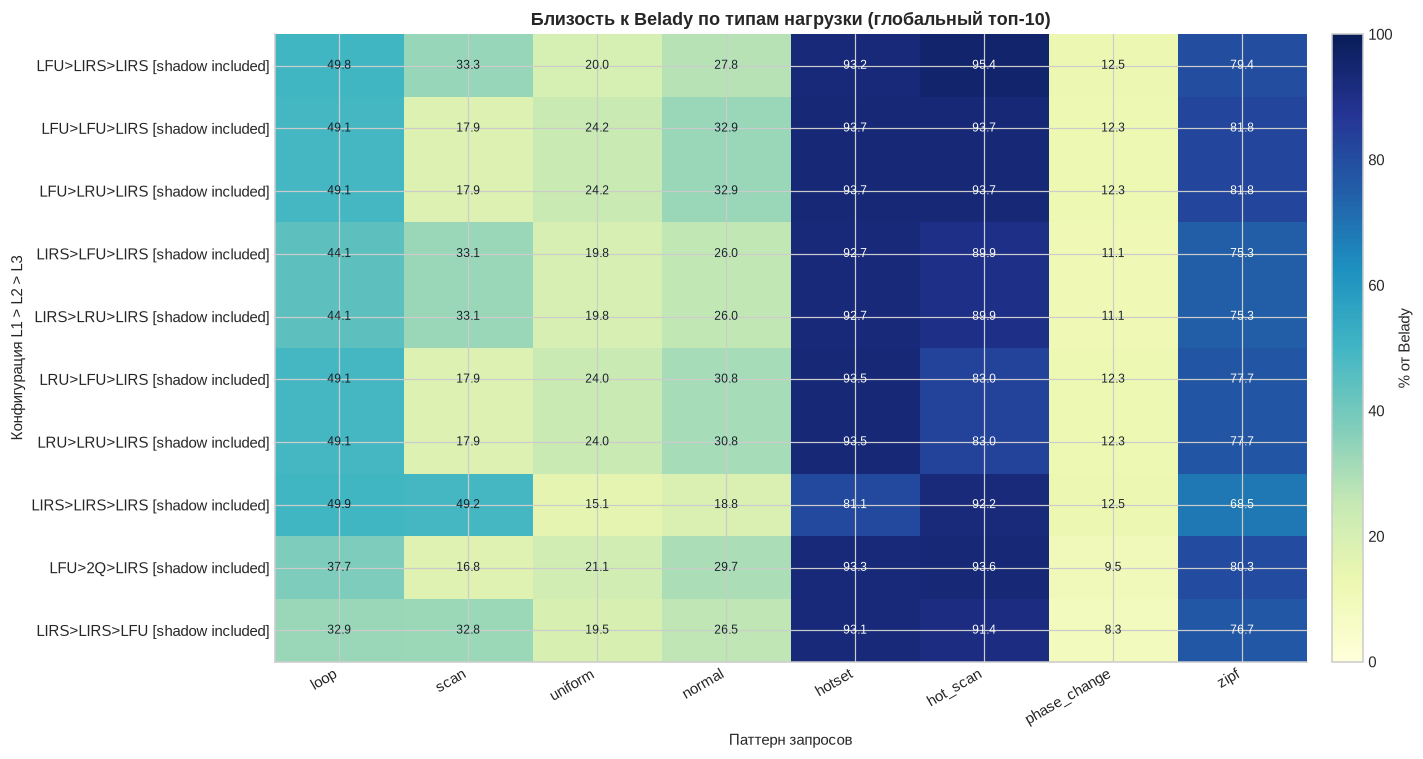

In [6]:
TOP_N_HEATMAP = 10
heatmap_configs = [str(item['policies']) for item in config_summary[:TOP_N_HEATMAP]]
pattern_scores: dict[tuple[str, str], list[float]] = defaultdict(list)
for row in rows:
    pattern_scores[(variant_label(row), str(row['pattern']))].append(float(row['percent_of_ideal']))

matrix = [
    [statistics.fmean(pattern_scores[(policies, pattern)]) for pattern in patterns]
    for policies in heatmap_configs
]

fig, ax = plt.subplots(figsize=(14, 7))
image = ax.imshow(matrix, aspect='auto', cmap='YlGnBu', vmin=0, vmax=100)
ax.set_xticks(range(len(patterns)), patterns, rotation=30, ha='right')
ax.set_yticks(range(len(heatmap_configs)), heatmap_configs)
for row_index, values in enumerate(matrix):
    for column_index, value in enumerate(values):
        ax.text(
            column_index, row_index, f'{value:.1f}',
            ha='center', va='center', fontsize=8,
            color='white' if value > 58 else '#16212a',
        )
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label('% от Belady')
ax.set_title('Близость к Belady по типам нагрузки (глобальный топ-10)')
ax.set_xlabel('Паттерн запросов')
ax.set_ylabel('Конфигурация L1 > L2 > L3')
fig.tight_layout()
plt.show()

In [7]:
print('Лучшая конфигурация для каждого паттерна')
print(f"{'pattern':<16} {'policies and mode':<45} {'% Belady':>10} {'hit-rate':>10}")
for pattern in patterns:
    candidates = []
    for policies in configs:
        group = [row for row in by_config[policies] if row['pattern'] == pattern]
        candidates.append((
            statistics.fmean(float(row['percent_of_ideal']) for row in group),
            statistics.fmean(float(row['hit_rate']) for row in group) * 100,
            policies,
        ))
    ideal_percent, hit_rate_percent, policies = max(candidates, key=lambda item: (item[0], item[1], item[2]))
    print(f'{pattern:<16} {policies:<45} {ideal_percent:>9.2f}% {hit_rate_percent:>9.2f}%')

Лучшая конфигурация для каждого паттерна
pattern          policies and mode                               % Belady   hit-rate
loop             LIRS>LIRS>LIRS [shadow included]                  49.91%     48.66%
scan             LIRS>LIRS>LIRS [shadow included]                  49.15%      5.79%
uniform          LRU>LRU>LRU [no shadow items]                     28.82%     12.36%
normal           LFU>LRU>LRU [no shadow items]                     40.54%     21.77%
hotset           LFU>LRU>LRU [no shadow items]                     94.19%     81.41%
hot_scan         LFU>LIRS>LIRS [shadow included]                   95.41%     51.71%
phase_change     LIRS>LIRS>LIRS [shadow included]                  12.55%     11.76%
zipf             LFU>LRU>LRU [no shadow items]                     85.87%     69.92%


## 5. Устойчивость и худшие случаи

Boxplot помогает не выбрать стратегию только по красивому среднему. Коробка показывает межквартильный диапазон, линия — медиану, ромб — среднее, а точки — редкие крайние результаты. Для production часто разумнее предпочесть немного меньшее среднее, но более высокий нижний хвост.

/tmp/ipykernel_63047/3563635450.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  boxes = ax.boxplot(


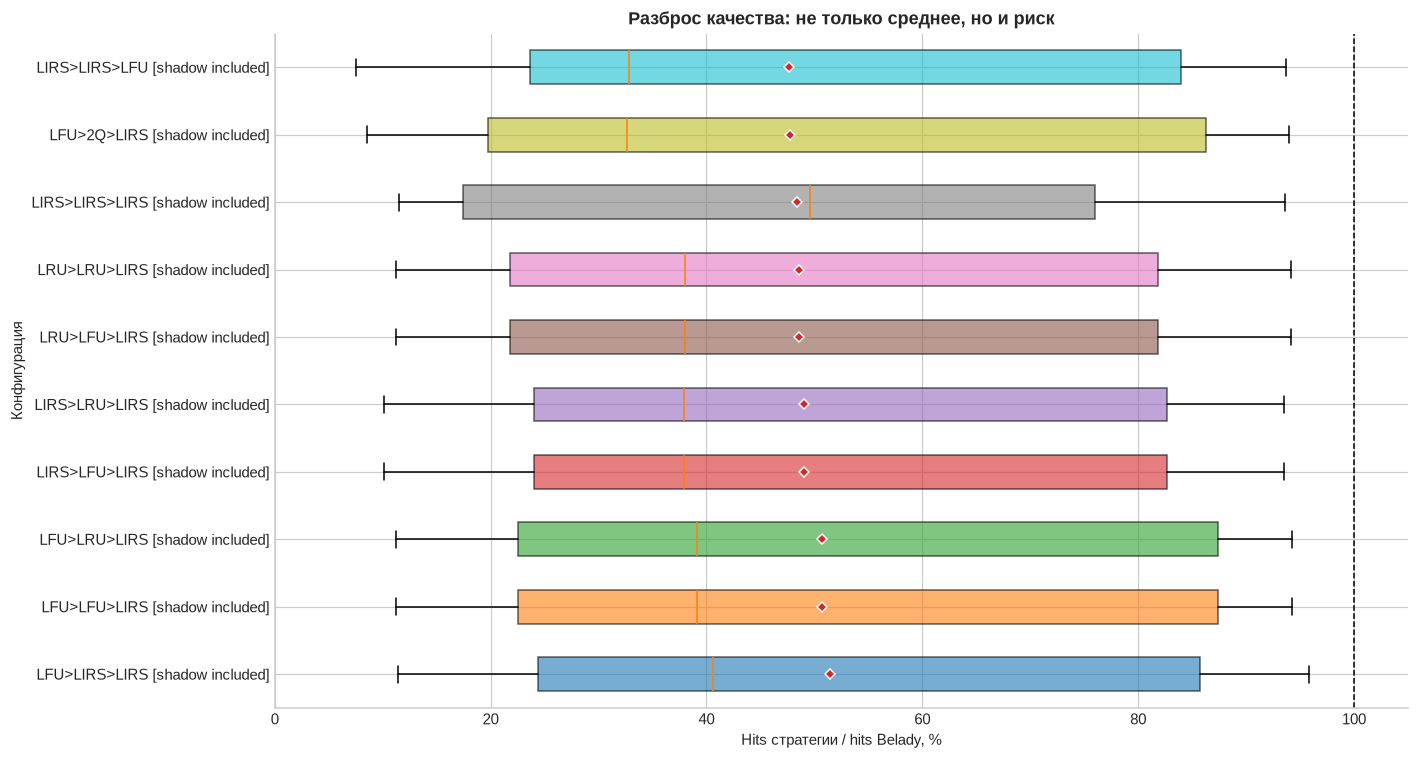

In [8]:
robust_configs = [str(item['policies']) for item in config_summary[:10]]
distributions = [
    [float(row['percent_of_ideal']) for row in by_config[policies]]
    for policies in robust_configs
]

fig, ax = plt.subplots(figsize=(13, 7))
boxes = ax.boxplot(
    distributions, vert=False, patch_artist=True, showmeans=True,
    meanprops={'marker': 'D', 'markerfacecolor': '#d62728', 'markeredgecolor': 'white', 'markersize': 5},
)
ax.set_yticks(range(1, len(robust_configs) + 1), robust_configs)
for index, box in enumerate(boxes['boxes']):
    box.set_facecolor(COLORS[index % len(COLORS)])
    box.set_alpha(0.60)
ax.axvline(100, color='black', linestyle='--', linewidth=1)
ax.set_xlim(0, 105)
ax.set_xlabel('Hits стратегии / hits Belady, %')
ax.set_ylabel('Конфигурация')
ax.set_title('Разброс качества: не только среднее, но и риск')
fig.tight_layout()
plt.show()

## 6. Чувствительность к размеру кэша

Здесь используется абсолютный hit-rate, а не процент от Belady: график отвечает на вопрос, насколько конкретной политике и режиму учёта помогает увеличение логического budget. Точки агрегируют все паттерны и seeds данного размера.

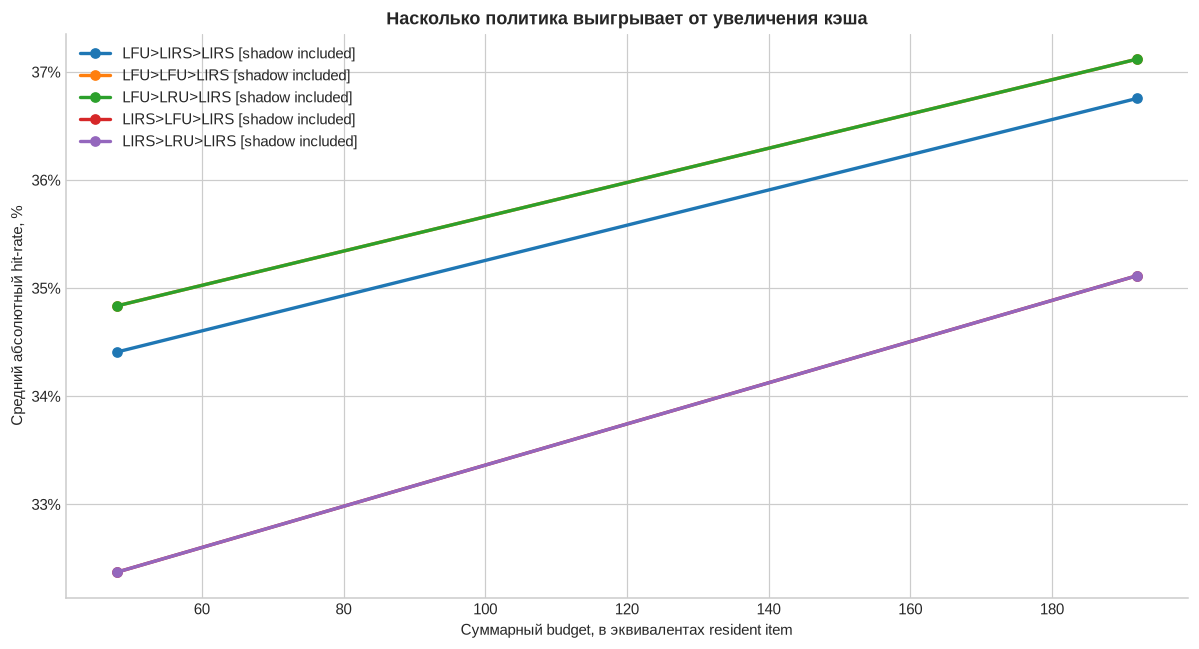

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))
for index, policies in enumerate(top5):
    by_capacity: dict[int, list[float]] = defaultdict(list)
    for row in by_config[policies]:
        by_capacity[int(row['total_capacity'])].append(float(row['hit_rate']) * 100)
    capacities = sorted(by_capacity)
    means = [statistics.fmean(by_capacity[capacity]) for capacity in capacities]
    ax.plot(capacities, means, marker='o', linewidth=2.2, color=COLORS[index], label=policies)

ax.set_xlabel('Суммарный budget, в эквивалентах resident item')
ax.set_ylabel('Средний абсолютный hit-rate, %')
ax.set_title('Насколько политика выигрывает от увеличения кэша')
ax.legend(frameon=False)
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:.0f}%'))
fig.tight_layout()
plt.show()

## 7. Цена shadow history при разном размере данных

Отдельный benchmark сравнивает `resident_only` и `resident_and_shadow` для однородных трёхуровневых 2Q, ARC и LIRS. Используются те же 48 workloads, но логический payload resident-элемента последовательно принимается равным текущему `sizeof(DefaultValue)`, 64, 256 и 1024 байтам.

В `resident_and_shadow` ключи history занимают часть общего byte-бюджета. Поэтому при маленьком payload штраф заметнее, а с ростом значения относительная цена одного shadow key уменьшается. `resident_only` показан как контрольная линия: размер значения не меняет его item capacity. Это логическая модель payload без allocator/container overhead.

Средний hit-rate, % от Belady
policy           mode                     current        64       256      1024
2Q>2Q>2Q         resident_only             42.49%    42.49%    42.49%    42.49%
2Q>2Q>2Q         resident_and_shadow       38.66%    41.99%    42.08%    42.08%
ARC>ARC>ARC      resident_only             42.50%    42.50%    42.50%    42.50%
ARC>ARC>ARC      resident_and_shadow       36.21%    41.79%    42.02%    42.02%
LIRS>LIRS>LIRS   resident_only             70.36%    70.36%    70.36%    70.36%
LIRS>LIRS>LIRS   resident_and_shadow       48.41%    67.68%    68.63%    68.63%


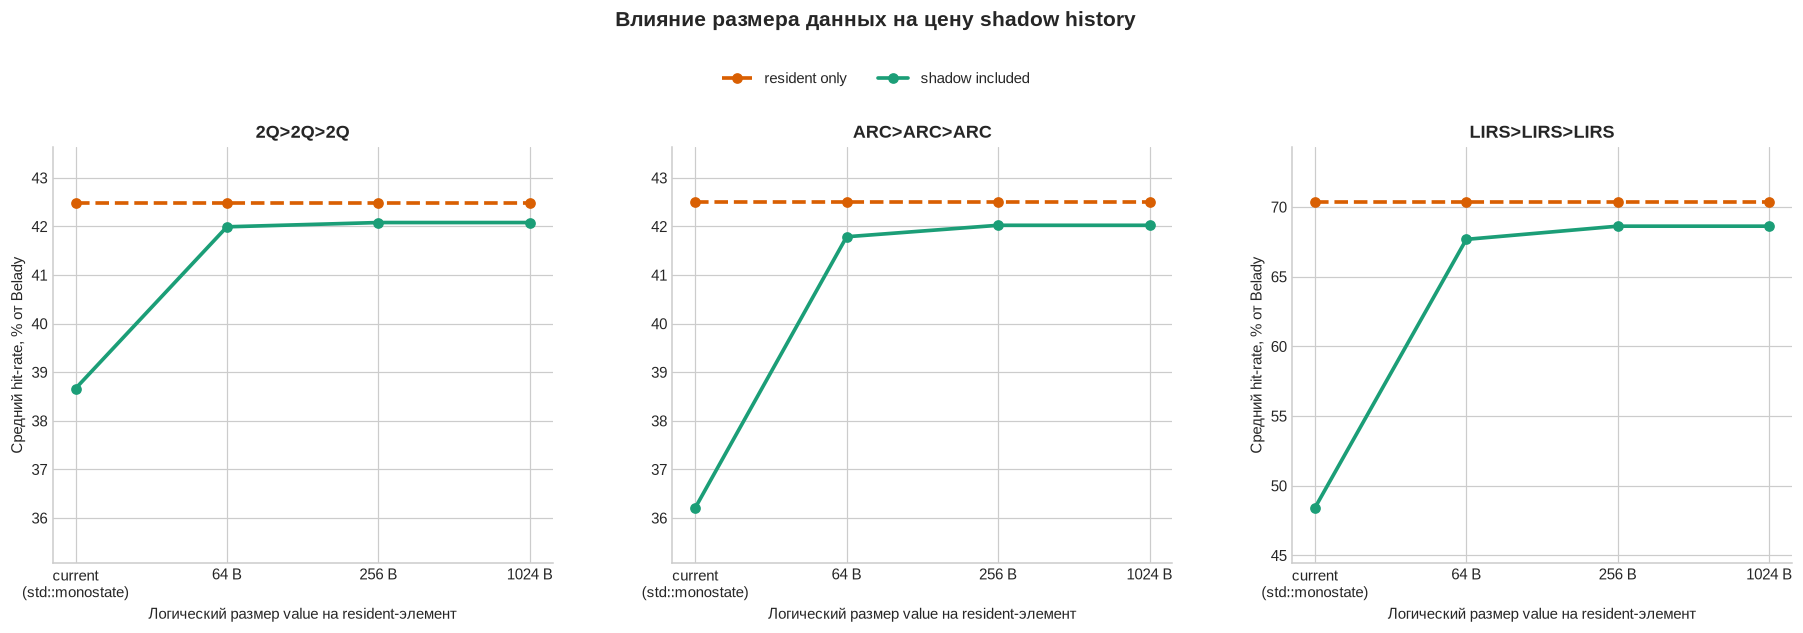

In [10]:
value_size_rows = load_results(VALUE_SIZE_RESULTS_CSV)
value_size_failed = [row for row in value_size_rows if row['status'] != 'ok']
if value_size_failed:
    raise RuntimeError(f'{len(value_size_failed)} value-size benchmark runs failed')

VALUE_SIZE_ORDER = ['current', '64', '256', '1024']
VALUE_SIZE_LABELS = ['current\n(std::monostate)', '64 B', '256 B', '1024 B']
VALUE_SIZE_POLICIES = ['2Q>2Q>2Q', 'ARC>ARC>ARC', 'LIRS>LIRS>LIRS']
VALUE_SIZE_MODES = ['resident_only', 'resident_and_shadow']

observed = {
    (str(row['policies']), str(row['capacity_mode']), str(row['value_bytes']), str(row['workload']))
    for row in value_size_rows
}
expected = {
    (policies, mode, value_bytes, workload)
    for policies in VALUE_SIZE_POLICIES
    for mode in VALUE_SIZE_MODES
    for value_bytes in VALUE_SIZE_ORDER
    for workload in workloads
}
assert observed == expected, f'value-size matrix is incomplete: missing={len(expected - observed)}, extra={len(observed - expected)}'

value_size_scores: dict[tuple[str, str, str], list[float]] = defaultdict(list)
for row in value_size_rows:
    key = (str(row['policies']), str(row['capacity_mode']), str(row['value_bytes']))
    value_size_scores[key].append(float(row['percent_of_ideal']))

print('Средний hit-rate, % от Belady')
print(f"{'policy':<16} {'mode':<22} " + ' '.join(f'{size:>9}' for size in VALUE_SIZE_ORDER))
for policies in VALUE_SIZE_POLICIES:
    for mode in VALUE_SIZE_MODES:
        means = [statistics.fmean(value_size_scores[(policies, mode, size)]) for size in VALUE_SIZE_ORDER]
        print(f"{policies:<16} {mode:<22} " + ' '.join(f'{value:>8.2f}%' for value in means))

fig, axes = plt.subplots(1, 3, figsize=(17, 6.2), sharey=False)
mode_style = {
    'resident_only': {'label': 'resident only', 'color': '#d95f02', 'linestyle': '--'},
    'resident_and_shadow': {'label': 'shadow included', 'color': '#1b9e77', 'linestyle': '-'},
}
x = list(range(len(VALUE_SIZE_ORDER)))
panel_values: dict[str, list[float]] = {}
for policies in VALUE_SIZE_POLICIES:
    panel_values[policies] = [
        statistics.fmean(value_size_scores[(policies, mode, size)])
        for mode in VALUE_SIZE_MODES
        for size in VALUE_SIZE_ORDER
    ]

def padded_limits(values: list[float]) -> tuple[float, float]:
    low, high = min(values), max(values)
    padding = max(1.0, (high - low) * 0.18)
    return max(0.0, low - padding), min(100.0, high + padding)

simple_limits = padded_limits(panel_values['2Q>2Q>2Q'] + panel_values['ARC>ARC>ARC'])
for ax, policies in zip(axes, VALUE_SIZE_POLICIES, strict=True):
    for mode in VALUE_SIZE_MODES:
        means = [statistics.fmean(value_size_scores[(policies, mode, size)]) for size in VALUE_SIZE_ORDER]
        style = mode_style[mode]
        ax.plot(x, means, marker='o', linewidth=2.4, markersize=6, **style)
    ax.set_xticks(x, VALUE_SIZE_LABELS)
    ax.set_title(policies)
    ax.set_xlabel('Логический размер value на resident-элемент')
    ax.set_ylim(*(simple_limits if policies != 'LIRS>LIRS>LIRS' else padded_limits(panel_values[policies])))
axes[0].set_ylabel('Средний hit-rate, % от Belady')
axes[2].set_ylabel('Средний hit-rate, % от Belady')
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle('Влияние размера данных на цену shadow history', y=0.98, fontsize=14, fontweight='bold')
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.91), ncol=2, frameon=False)
fig.subplots_adjust(left=0.06, right=0.99, bottom=0.17, top=0.78, wspace=0.24)
plt.show()

## Как читать результаты

1. Начните с heatmap и выберите строки, сильные на паттернах, похожих на вашу нагрузку.
2. Проверьте boxplot: важен не только mean, но и провалы на отдельных traces.
3. По графику capacity оцените отдачу от дополнительной памяти.
4. По отдельному графику payload size оцените, насколько цена shadow history существенна для реального размера значения.
5. Повторите benchmark на обезличенных production traces и с реалистичными размерами уровней.

Не интерпретируйте процент от Belady без абсолютного hit-rate: 95% от небольшого идеального hit-rate может быть практически слабее, чем меньшее относительное значение на workload с большим числом переиспользований.